1. Dataset Download

In [1]:
# Install Kaggle API
!pip install kaggle

import json

kaggle_info = {
    "username": "USERNAME",
    "key": "APIKEY"
}

# Create Kaggle credentials file
with open("kaggle.json", "w") as f:
    json.dump(kaggle_info, f)

# Configure Kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download and extract GTSRB dataset
!kaggle datasets download -d meowmeowmeowmeowmeow/gtsrb-german-traffic-sign
!unzip -q gtsrb-german-traffic-sign.zip

Dataset URL: https://www.kaggle.com/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign
License(s): CC0-1.0
100% 612M/612M [00:06<00:00, 94.8MB/s]



2. Imports

In [2]:
import os
import pandas as pd
import numpy as np

from PIL import Image

import torch
import torch.nn as nn

from torchvision import transforms

from torch.utils.data import (
    Dataset,
    DataLoader,
    random_split
)

import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix

3. Explore Dataset

Number of classes: 43
Image size: (29, 30)


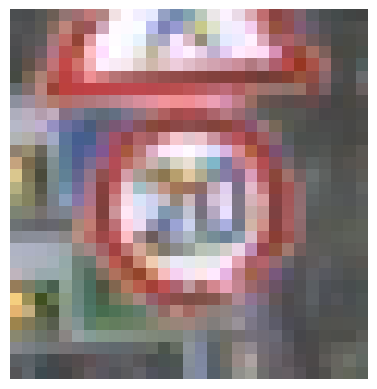

In [3]:
data_dir = "/content/Train"

classes = os.listdir(data_dir)

print("Number of classes:", len(classes))

sample_path = "/content/Train/0/00000_00000_00000.png"

img = Image.open(sample_path)

plt.imshow(img)
plt.axis("off")

print("Image size:", img.size)

4. Image Transformations

In [4]:
IMG_SIZE = 64

# Training transformations (data augmentation)
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),
    transforms.ToTensor()
])

# Validation/Test transformations
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

5. CNN Model

In [5]:
class TrafficCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(

            nn.Linear(128 * 8 * 8, 512),
            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(512, 43)
        )

    def forward(self, x):

        x = self.conv(x)

        x = x.view(x.size(0), -1)

        return self.fc(x)

6. Training Dataset

In [6]:
class GTSRBDataset(Dataset):

    def __init__(self, root_dir, transform=None):

        self.root_dir = root_dir
        self.transform = transform

        self.images = []
        self.labels = []

        # IMPORTANT:
        # Sort numerically instead of alphabetically

        self.classes = sorted(
            os.listdir(root_dir),
            key=lambda x: int(x)
        )

        for label, cls in enumerate(self.classes):

            class_path = os.path.join(root_dir, cls)

            for img_name in os.listdir(class_path):

                self.images.append(
                    os.path.join(class_path, img_name)
                )

                self.labels.append(label)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        image = Image.open(
            self.images[idx]
        ).convert("RGB")

        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

7. Create Dataset

In [7]:
dataset = GTSRBDataset(
    "/content/Train",
    transform=train_transform
)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_ds, val_ds = random_split(
    dataset,
    [train_size, val_size]
)

train_loader = DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=32,
    shuffle=False
)

8. Model Setup

In [8]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

model = TrafficCNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

9. Training Loop

In [9]:
epochs = 10

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(
        f"Epoch {epoch+1}/{epochs}, "
        f"Loss: {total_loss/len(train_loader):.4f}"
    )

Epoch 1/10, Loss: 1.3820
Epoch 2/10, Loss: 0.2272
Epoch 3/10, Loss: 0.1011
Epoch 4/10, Loss: 0.0726
Epoch 5/10, Loss: 0.0543
Epoch 6/10, Loss: 0.0471
Epoch 7/10, Loss: 0.0404
Epoch 8/10, Loss: 0.0380
Epoch 9/10, Loss: 0.0281
Epoch 10/10, Loss: 0.0300


10. Validation Accuracy

In [10]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()

        total += labels.size(0)

print(
    "Validation Accuracy:",
    correct / total
)

Validation Accuracy: 0.994899260392757


11. Official Test Dataset

In [11]:
class GTSRBTestDataset(Dataset):

    def __init__(
        self,
        csv_file,
        img_root,
        transform=None
    ):

        self.data = pd.read_csv(csv_file)

        self.img_root = img_root

        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

        row = self.data.iloc[idx]

        image_path = os.path.join(
            self.img_root,
            row["Path"]
        )

        image = Image.open(
            image_path
        ).convert("RGB")

        label = int(row["ClassId"])

        if self.transform:
            image = self.transform(image)

        return image, label

12. Test Loader

In [12]:
test_dataset = GTSRBTestDataset(
    csv_file="/content/Test.csv",
    img_root="/content",
    transform=test_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

13. Test Accuracy

In [13]:
model.eval()

correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()

        total += labels.size(0)

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

print(
    "Test Accuracy:",
    correct / total
)

Test Accuracy: 0.9566112430720507


14. Confusion Matrix

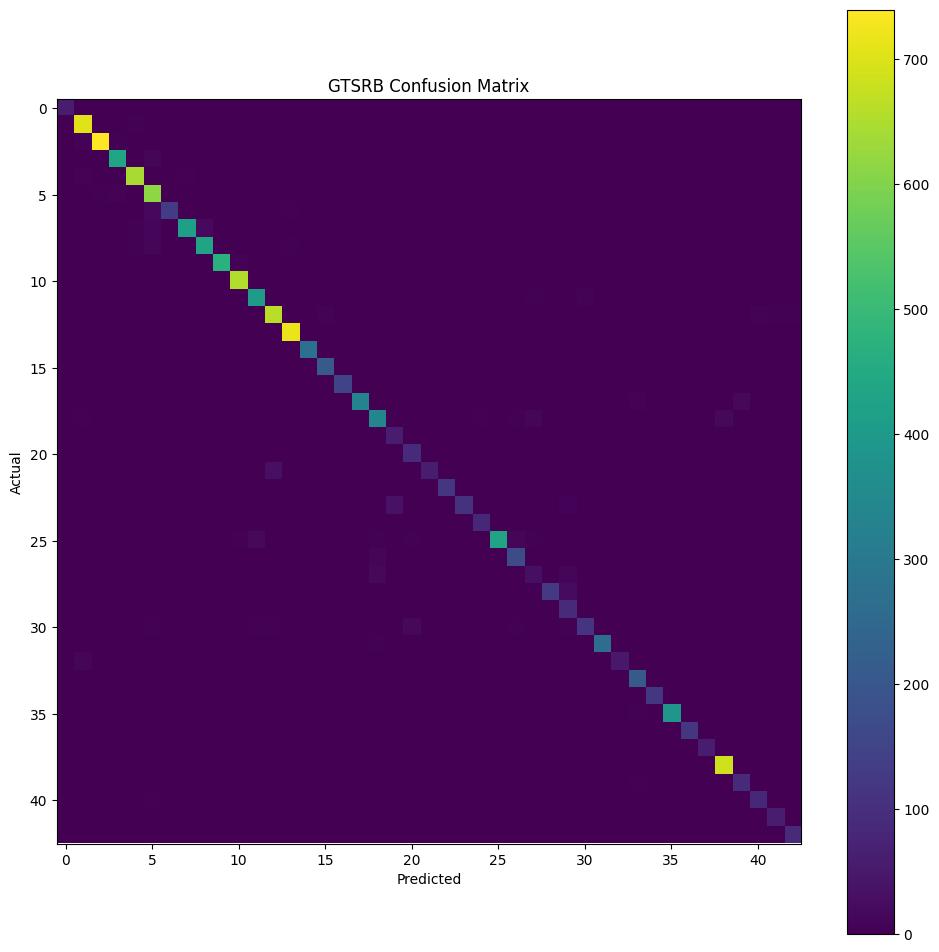

In [14]:
cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(12, 12))

plt.imshow(cm)

plt.title(
    "GTSRB Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.colorbar()

plt.show()

15. Normalized Confusion Matrix

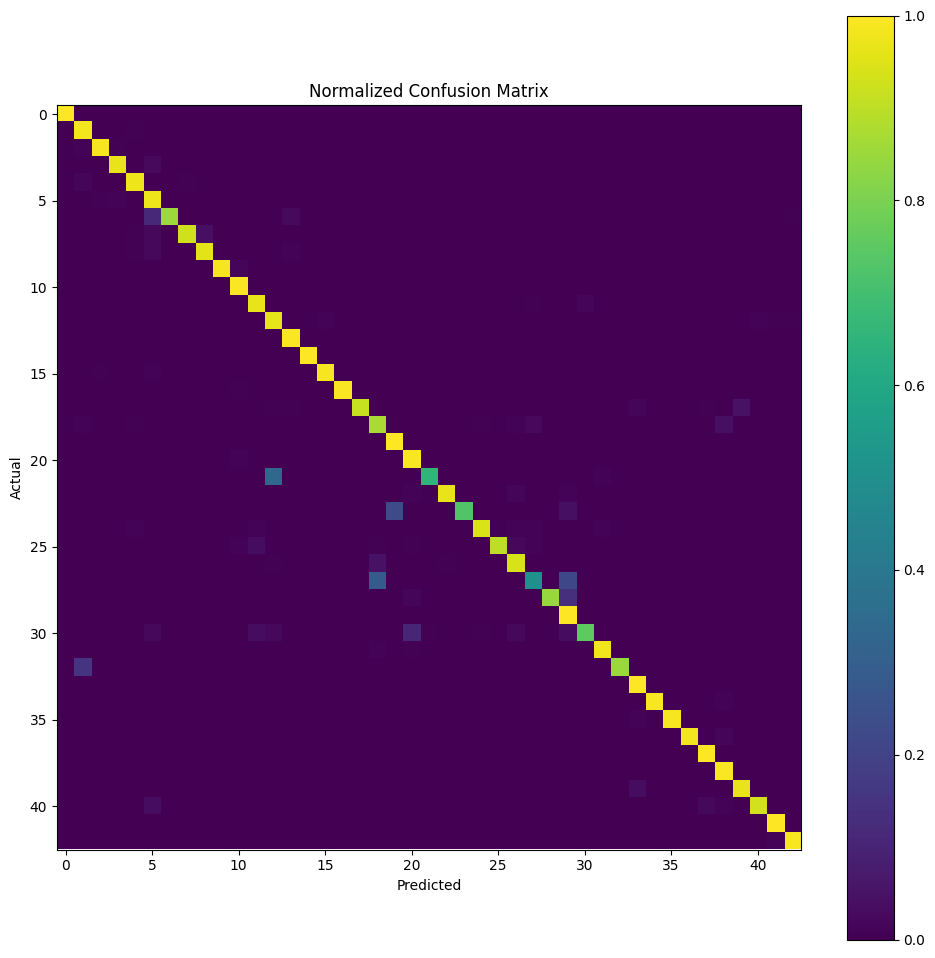

In [15]:
cm_norm = (
    cm.astype(float)
    / cm.sum(axis=1, keepdims=True)
)

plt.figure(figsize=(12, 12))

plt.imshow(cm_norm)

plt.title(
    "Normalized Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.colorbar()

plt.show()